# Example for bssunfold package with Compressive Sensing (CS)

This notebook demonstrates the `unfold_cs` method, which unfolds a neutron
spectrum using **Compressive Sensing (CS)**. The spectrum is represented
sparsely in a learned dictionary (K-SVD), sparse coding is performed with
**OMP**, and reconstruction is done with the **SL0** algorithm.

CS is especially well suited for the highly underdetermined problem where the
number of energy groups greatly exceeds the number of detector readings.

In [1]:
# %pip install bssunfold pandas numpy matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from bssunfold import Detector, RF_LANL

## Load the response functions file for the BSS
- first column: Energy in MeV
- other columns: detector responses for the set of moderator spheres

Number of energy bins: 60
Number of detectors: 11


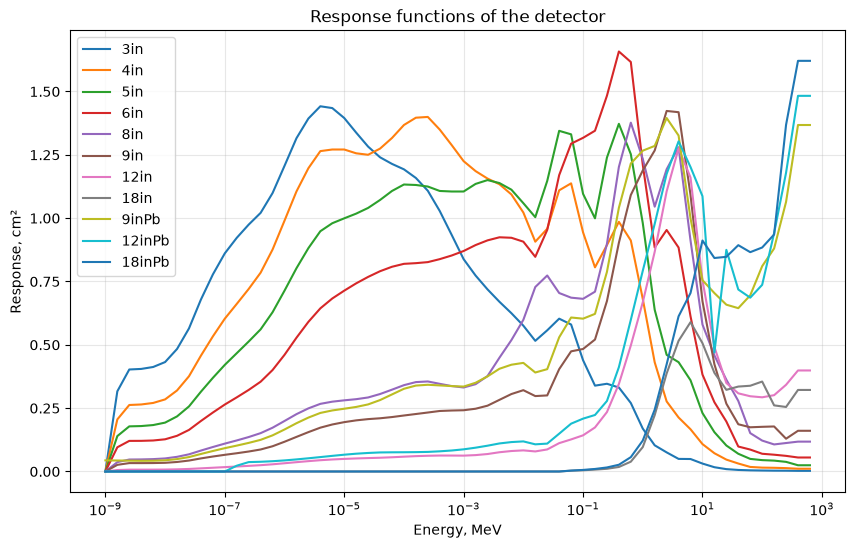

In [3]:
det = Detector(RF_LANL)
print(f"Number of energy bins: {det.n_energy_bins}")
print(f"Number of detectors: {len(det.detector_names)}")
det.plot_response_functions()

## Reference spectrum (ISO Cf-252)

We use a reference spectrum to compute synthetic detector readings, then try
to recover the spectrum from those readings using CS.

In [4]:
reference_spectrum = {
    "E_MeV": [
        1e-09, 1.5848931924611136e-09, 2.5118864315095803e-09,
        3.981071705534973e-09, 6.309573444801934e-09, 1e-08,
        1.5848931924611143e-08, 2.511886431509581e-08, 3.9810717055349736e-08,
        6.309573444801934e-08, 1.0000000000000001e-07, 1.5848931924611143e-07,
        2.5118864315095823e-07, 3.9810717055349735e-07, 6.309573444801937e-07,
        1.0000000000000002e-06, 1.584893192461114e-06, 2.5118864315095823e-06,
        3.981071705534973e-06, 6.309573444801937e-06, 1e-05,
        1.584893192461114e-05, 2.5118864315095822e-05, 3.9810717055349776e-05,
        6.309573444801943e-05, 0.0001, 0.00015848931924611142,
        0.0002511886431509582, 0.0003981071705534978, 0.0006309573444801943,
        0.001, 0.0015848931924611143, 0.0025118864315095825,
        0.003981071705534978, 0.006309573444801942, 0.01,
        0.01584893192461114, 0.025118864315095826, 0.039810717055349776,
        0.06309573444801943, 0.1, 0.15848931924611173, 0.25118864315095824,
        0.3981071705534969, 0.6309573444801944, 1.0, 1.5848931924611174,
        2.5118864315095824, 3.9810717055349856, 6.309573444801943, 10.0,
        15.848931924611176, 25.118864315095824, 39.810717055349855,
        63.09573444801943, 100.0, 158.48931924611173, 251.18864315095823,
        398.1071705534986, 630.9573444801944,
    ],
    "Phi": [
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0002193244132568562,
        0.000922, 0.0017977302145640818, 0.0033934229230273556,
        0.00638236969883396, 0.01212580290671056, 0.0237, 0.04468185467401807,
        0.0822779218679577, 0.1450462719353082, 0.2413649401952857, 0.359,
        0.45221093414611185, 0.4338707690763234, 0.2708850368693928,
        0.0856762250762, 0.00427, 0.0004258199483775139, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0,
    ],
}

## Get effective readings for the reference spectrum

In [5]:
readings = det.get_effective_readings_for_spectra(reference_spectrum)
readings

{'3in': 0.252513702215002,
 '4in': 0.8892263811772403,
 '5in': 1.382578000964167,
 '6in': 2.1243027258756557,
 '8in': 2.4398141975356498,
 '9in': 2.6419605932200074,
 '12in': 2.025604901091247,
 '18in': 0.7146750985513488,
 '9inPb': 2.638272020811322,
 '12inPb': 2.2028350450016783,
 '18inPb': 0.8586014689131867}

## Unfold with Compressive Sensing

We add a small amount of noise to the readings and unfold with `unfold_cs`.
The `n_atoms` parameter controls the dictionary size and `sparsity` the target
sparsity of the coefficient vector. We also compare against the GRAVEL method.

In [6]:
noise_level = 0.01  # 1% of the total readings
nreadings = det._add_noise(readings, noise_level=noise_level)

results = {
    "CS": det.unfold_cs(
        nreadings,
        n_atoms=80,
        sparsity=6,
        max_iterations=200,
        random_state=0,
        save_result=False,
    ),
    "Gravel": det.unfold_gravel(
        nreadings,
        save_result=False,
    ),
}

for name, res in results.items():
    print(f"{name}: residual_norm = {res['residual_norm']:.4f}")

CS: residual_norm = 1.4953
Gravel: residual_norm = 0.0339


## Plot the unfolded spectra and effective readings

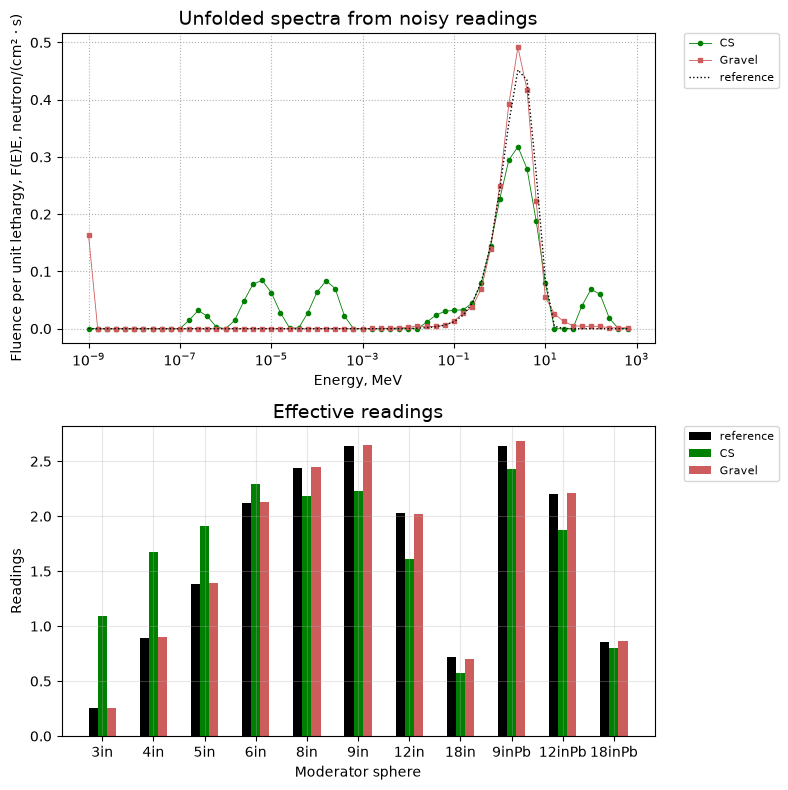

In [7]:
markers = ["o", "s", "D"]
colors = ["black", "green", "indianred"]
fig, ax = plt.subplots(2, 1, figsize=(8, 8))

# First plot: spectra
for i, method in enumerate(results.keys()):
    ax[0].plot(
        results[method]["energy"],
        results[method]["spectrum"],
        label=method,
        color=colors[i + 1],
        ls="-",
        marker=markers[i],
        markersize=3,
        linewidth=0.6,
    )

ax[0].plot(
    reference_spectrum["E_MeV"],
    reference_spectrum["Phi"],
    label="reference",
    linewidth=1,
    linestyle=":",
    color=colors[0],
)

ax[0].set_xlabel("Energy, MeV")
ax[0].set_ylabel("Fluence per unit lethargy, F(E)E, neutron/(cm² · s)")
ax[0].set_xscale("log")
ax[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0, fontsize=8)
ax[0].grid(True, which="both", ls=":")
ax[0].set_title("Unfolded spectra from noisy readings", fontsize=14)

# Second plot: effective readings (bar chart)
data_sources = {"reference": list(readings.values())}
for method in results.keys():
    data_sources[method] = [
        results[method]["effective_readings"][det] for det in readings.keys()
    ]

labels = list(readings.keys())
x = np.arange(len(labels))
width = 0.8 / (len(data_sources) * 1.5)
n_bars = len(data_sources)

for i, (label, values) in enumerate(data_sources.items()):
    offset = (i - n_bars / 2 + 0.5) * width
    ax[1].bar(x + offset, values, width, label=label, alpha=1, color=colors[i])

ax[1].set_xticks(x, labels)
ax[1].set_xlabel("Moderator sphere")
ax[1].set_ylabel("Readings")
ax[1].set_title("Effective readings", fontsize=14)
ax[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0, fontsize=8)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Monte-Carlo uncertainty

CS unfolding also supports Monte-Carlo uncertainty estimation via the
`calculate_errors` flag.

In [8]:
res_unc = det.unfold_cs(
    nreadings,
    n_atoms=80,
    sparsity=6,
    max_iterations=200,
    calculate_errors=True,
    n_montecarlo=20,
    noise_level=0.01,
    random_state=0,
    save_result=False,
)

print("spectrum_uncert_mean:", res_unc["spectrum_uncert_mean"][:5])
print("spectrum_uncert_std:", res_unc["spectrum_uncert_std"][:5])

spectrum_uncert_mean: [0.13909471 0.12522106 0.09161373 0.05326278 0.02909356]
spectrum_uncert_std: [0.11229426 0.10384984 0.08160355 0.05816854 0.03503196]
